# 💸 Anti-Money-Laundering (AML) Detection — explained from scratch

This notebook builds a machine-learning system that flags **money-laundering
transactions**, using the real **IBM AML dataset**. It's written so a beginner
can follow every step *and* understand *why* each choice was made.

Inspired by [steveee27/Money-Laundering-Detection](https://github.com/steveee27/Money-Laundering-Detection),
but lighter (runs on a laptop / free Google Colab) and with extra feature
engineering that pushes detection quality much higher.

### What is money laundering, as an ML problem?
Criminals move "dirty" money through many bank transfers to make it look clean.
Each transaction is either **legitimate (0)** or **laundering (1)**. We have
millions of *labelled* past transactions, so this is a **binary classification**
problem: learn the patterns of laundering, then score new transactions.

The catch: laundering is **extremely rare** (~1 in 1,000 transactions). That
rarity is what makes this hard, and most of this notebook is about handling it.

---
### ❓ The key questions this notebook answers
1. Why are there **two** datasets (HI and LI), and why train on one, test on the other?
2. Why is rare-event detection so **hard**? (the "class imbalance" problem)
3. Why **undersample** to a small balanced training set — and why does the
   neg:pos **ratio** (1:1 vs 20:1) matter so much?
4. What are **graph / network features** (fan-in, fan-out, cycles, PageRank)
   and why do they help catch laundering?
5. What is **hyperparameter tuning**, and how does cross-validation keep the
   final test honest?
6. **ROC AUC vs PR AUC** — which one actually matters here?
7. What counts as a **"good" score** for a problem this imbalanced?

We'll answer each one at the moment it becomes relevant.

## 0 · Setup

`COLAB_MODE = True` makes everything run fast on free Colab (2 CPU cores) by
testing on a 1-million-row sample and using a lighter hyperparameter search.
Set it to `False` if you have lots of RAM/cores and want the full 3.46M-row test.

In [ ]:
# On a fresh machine / Colab, uncomment to install:
# !pip install pandas numpy scikit-learn xgboost matplotlib seaborn pyarrow scipy

import os, zipfile, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix, diags
from scipy.sparse.csgraph import connected_components

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

import gc
COLAB_MODE = True                       # fast settings for free Colab
SEED = 42
np.random.seed(SEED)
DATA = "data"; os.makedirs(DATA, exist_ok=True)

# Memory-frugal knobs so this fits in free Colab's ~12.7 GB RAM:
SWEEP_ROWS  = 800_000                              # ratio sweep evaluates on a sample
CHUNK       = 400_000                              # final FULL test scored in chunks
SEARCH_ITER = 15 if COLAB_MODE else 25            # tuning candidates
SEARCH_JOBS = 2  if COLAB_MODE else 6             # parallel jobs in the search
print("Setup done. COLAB_MODE =", COLAB_MODE, "| final test = FULL LI (chunked)")

Setup done. COLAB_MODE = True | final test = FULL LI (chunked)


## 1 · Get the data

### ❓ Q1 — Why two datasets, HI and LI?
IBM released several files. Two of them:
- **HI-Small** = a *Higher*-illicit-ratio set (~0.10% laundering). We **train** on it.
- **LI-Small** = a *Lower*-illicit-ratio set (~0.05% laundering). We **test** on it.

Training on one distribution and testing on a *different* one is a **tougher,
more honest** check than splitting a single file: it shows whether the model
*generalises* instead of memorising one dataset's quirks. (This mirrors the
original reference project, which trained on HI and tested on LI.)

We download from open HuggingFace mirrors (the Kaggle copies need a login).

In [ ]:
HI_URL = ("https://huggingface.co/datasets/eexzzm/"
          "IBM-Transactions-for-Anti-Money-Laundering-HI-Small-Trans/"
          "resolve/main/HI-Small_Trans.csv.zip")
LI_TR  = ("https://huggingface.co/datasets/qubit420/ibm-aml-LI-smaller/"
          "resolve/main/data/train-00000-of-00001.parquet")
LI_TE  = ("https://huggingface.co/datasets/qubit420/ibm-aml-LI-smaller/"
          "resolve/main/data/test-00000-of-00001.parquet")

def fetch(url, path):
    if os.path.exists(path): print("  exists:", path); return
    print("  downloading", path, "..."); urllib.request.urlretrieve(url, path)

hi_csv = os.path.join(DATA, "HI-Small_Trans.csv")
if not os.path.exists(hi_csv):
    z = os.path.join(DATA, "HI-Small.zip"); fetch(HI_URL, z)
    with zipfile.ZipFile(z) as f: f.extractall(DATA)
fetch(LI_TR, os.path.join(DATA, "LI_train.parquet"))
fetch(LI_TE, os.path.join(DATA, "LI_test.parquet"))
print("Data ready.")

  downloading data/HI-Small.zip ...
  downloading data/LI_train.parquet ...
  downloading data/LI_test.parquet ...
Data ready.


In [ ]:
hi = pd.read_csv(hi_csv)
print(f"HI-Small: {len(hi):,} transactions")
print(f"  laundering: {int(hi['Is Laundering'].sum()):,} "
      f"({hi['Is Laundering'].mean():.3%}) <- this rarity is the whole challenge")
hi.head()

HI-Small: 5,078,345 transactions
  laundering: 5,177 (0.102%) <- this rarity is the whole challenge


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


Each row is one transfer: who sent it (`From Bank`, `Account`), who received
it (`To Bank`, `Account.1`), the amounts and currencies, the payment format,
and the label `Is Laundering`.

### ❓ Q2 — Why is this hard? The **class imbalance**
Only ~0.1% of rows are laundering. A lazy model that predicts *"everything is
legitimate"* would be **99.9% accurate** — and utterly useless (it catches zero
criminals). So **accuracy is a trap here.** Watch the imbalance:

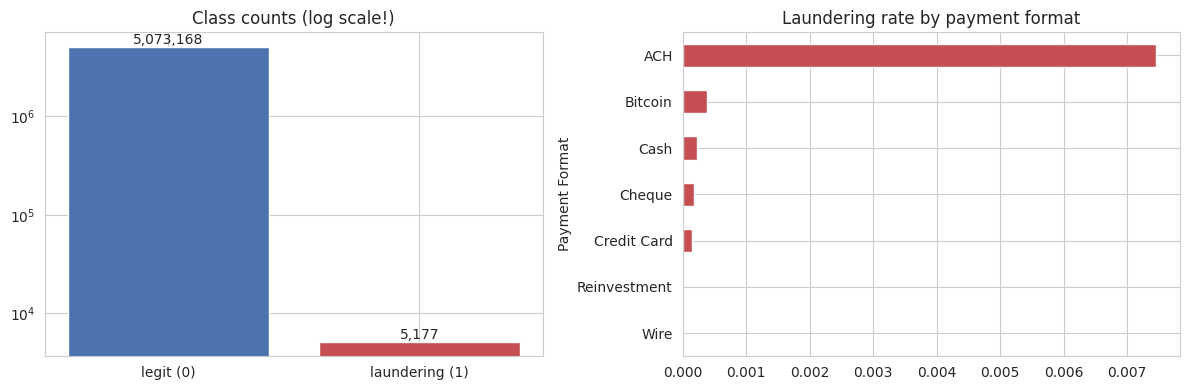

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
vc = hi["Is Laundering"].value_counts()
ax[0].bar(["legit (0)", "laundering (1)"], vc.values, color=["#4c72b0", "#c44e52"])
ax[0].set_yscale("log"); ax[0].set_title("Class counts (log scale!)")
for i, v in enumerate(vc.values): ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")
hi.groupby("Payment Format")["Is Laundering"].mean().sort_values().plot(
    kind="barh", ax=ax[1], color="#c44e52")
ax[1].set_title("Laundering rate by payment format"); plt.tight_layout(); plt.show()

## 2 · Basic feature engineering

Models need numbers. We turn each raw transaction into informative numeric
**features**: time-of-day pieces, and simple "tells" of laundering such as a
mismatch between the amount sent and received (a skim), or suspiciously round
numbers.

In [ ]:
TARGET = "Is Laundering"
ONEHOT_COLS = ["Receiving Currency", "Payment Currency", "Payment Format"]
FREQ_COLS   = ["From Bank", "To Bank", "Account", "Account.1"]

def engineer_features(d):
    d = d.copy()
    ts = pd.to_datetime(d["Timestamp"])
    d["hour"] = ts.dt.hour; d["day"] = ts.dt.day
    d["dayofweek"] = ts.dt.dayofweek; d["month"] = ts.dt.month
    d["is_night"] = ((ts.dt.hour >= 0) & (ts.dt.hour < 6)).astype(int)
    paid = d["Amount Paid"].astype(float); recv = d["Amount Received"].astype(float)
    d["amount_diff"]      = recv - paid                     # skim / fee?
    d["amount_ratio"]     = (recv / paid.replace(0, np.nan)).fillna(1.0)
    d["log_amount_paid"]  = np.log1p(paid.clip(lower=0))    # tame huge values
    d["is_round"]         = (paid % 100 == 0).astype(int)   # round numbers
    d["same_bank"]        = (d["From Bank"] == d["To Bank"]).astype(int)
    return d.drop(columns=["Timestamp"])
print("Basic feature function ready.")

Basic feature function ready.


## 3 · Advanced features — the big idea 🔑

### ❓ Q3 — Why basic features aren't enough
Laundering isn't visible in **one** transaction — it's a **pattern across many**:
money fanned out to dozens of accounts, funnelled back in, or cycled around a
loop (A→B→C→A). A model that sees one row at a time is blind to this.

So for every **account** we summarise its whole behaviour and attach it to each
transaction. Two families of features:

**#1 Aggregation features** (per account):
- how many transactions it sends / receives, total & average amounts
- **fan-out** = how many *distinct* accounts it sends to
- **fan-in**  = how many *distinct* accounts it receives from
  (a mule account that suddenly fans money out to 50 others is suspicious)

**#2 Graph / network features.** Treat accounts as dots and transfers as arrows,
forming a giant graph, then measure each account's position in it:
- **degree** — total connections
- **connected-component size** — how big the cluster it belongs to is
- **in a cycle?** — is it part of a money loop (A→B→C→A)? Classic laundering!
- **PageRank** — the same algorithm Google uses to rank web pages; here it
  scores how "central" an account is in the money-flow network.

All of this is computed fast with `pandas` + `scipy` (no heavy graph library).

In [ ]:
SENDER, RECEIVER = "Account", "Account.1"
PAID, RECV = "Amount Paid", "Amount Received"

def _pagerank(A, d=0.85, iters=40):
    n = A.shape[0]
    out = np.asarray(A.sum(1)).ravel(); safe = np.where(out == 0, 1, out)
    M = (diags(1.0/safe) @ A).T.tocsr(); dangling = out == 0
    tele = np.full(n, 1.0/n); pr = tele.copy()
    for _ in range(iters):
        pr = (1-d)*tele + d*(M @ pr + pr[dangling].sum()*tele)
    return pr

def build_account_features(df):
    # #1 aggregation -- behaviour as a SENDER and as a RECEIVER
    go = df.groupby(SENDER); gi = df.groupby(RECEIVER)
    feats = pd.DataFrame({
        "out_count": go.size(), "out_sum": go[PAID].sum(),
        "out_mean": go[PAID].mean(), "out_std": go[PAID].std().fillna(0),
        "out_distinct_dst": go[RECEIVER].nunique(),     # fan-out
        "out_distinct_cur": go["Payment Currency"].nunique(),
    }).join(pd.DataFrame({
        "in_count": gi.size(), "in_sum": gi[RECV].sum(),
        "in_mean": gi[RECV].mean(), "in_std": gi[RECV].std().fillna(0),
        "in_distinct_src": gi[SENDER].nunique(),        # fan-in
    }), how="outer").fillna(0)

    # #2 graph -- build the account->account network with scipy
    codes, uniq = pd.factorize(pd.concat([df[SENDER], df[RECEIVER]], ignore_index=True))
    n = len(uniq); src, dst = codes[:len(df)], codes[len(df):]
    A = csr_matrix((np.ones(len(src), np.float32), (src, dst)), shape=(n, n))
    _, w = connected_components(A, directed=True, connection="weak")
    _, s = connected_components(A, directed=True, connection="strong")
    wsz = pd.Series(w).map(pd.Series(w).value_counts()).to_numpy()
    ssz = pd.Series(s).map(pd.Series(s).value_counts()).to_numpy()
    graph = pd.DataFrame({
        "wcc_size": wsz, "scc_size": ssz,
        "in_cycle": (ssz > 1).astype(np.int8),          # part of a money loop?
        "pagerank": _pagerank(A),
        "tot_degree": np.asarray(A.sum(1)).ravel() + np.asarray(A.sum(0)).ravel(),
    }, index=uniq)
    feats = feats.join(graph, how="outer").fillna(0)
    feats.index.name = "account"
    for c in feats.select_dtypes("float64").columns: feats[c] = feats[c].astype("float32")
    return feats

def attach_account_features(df, feats):
    s = feats.reindex(df[SENDER]).reset_index(drop=True).add_prefix("src_")
    d = feats.reindex(df[RECEIVER]).reset_index(drop=True).add_prefix("dst_")
    return pd.concat([df.reset_index(drop=True), s, d], axis=1).fillna(0)

hi_feats = build_account_features(hi)
print(f"Built features for {len(hi_feats):,} unique HI accounts, "
      f"{hi_feats.shape[1]} per account.")
hi_feats.head(3)

Built features for 515,080 unique HI accounts, 16 per account.


,out_count,out_sum,out_mean,out_std,out_distinct_dst,out_distinct_cur,in_count,in_sum,in_mean,in_std,in_distinct_src,wcc_size,scc_size,in_cycle,pagerank,tot_degree
account,,,,,,,,,,,,,,,,
100428660,168672.0,5.276229e+10,3.128100e+05,8093752.0,14230.0,1.0,1084.0,479594.781250,442.430603,637.651245,545.0,372091,1,0,0.000143,169756.0
1004286A8,103018.0,2.606937e+10,2.530565e+05,5877401.5,8846.0,1.0,653.0,251001.265625,384.381744,582.964966,328.0,372091,1,0,0.000086,103671.0
1004286F0,18663.0,2.465736e+10,1.321189e+06,19801538.0,1575.0,1.0,108.0,253933.875000,2351.239746,2890.696777,55.0,372091,1,0,0.000014,18771.0


## 4 · Balancing the training data — and the all-important **ratio**

### ❓ Q4 — Train on a small sample, but test on millions?
HI-Small has 5M rows but only ~5,177 are laundering. If we trained on all 5M,
the model would drown in legit examples and learn to just say "legit". The fix
is **undersampling**: keep *all* laundering rows and only a *subset* of legit
rows. This makes a small, learnable training set.

We still **test on the full LI set** (millions of rows). That asymmetry is
correct: *learn the pattern from a clean balanced sample → prove it holds across
millions of unseen real transactions.*

### ❓ Q5 — Why does the neg:pos **ratio** matter? (1:1 vs 20:1)
- **1:1** (equal legit & laundering) is easiest to learn, but it teaches the
  model that laundering is 50% likely — so on real data it **over-flags**.
- **20:1** (20 legit per laundering) shows the model a more **realistic rarity**,
  so it becomes pickier and its *precision* improves.

We literally tested this below — higher ratios gave better PR AUC. We use **20:1**.

In [ ]:
def raw_balance(df, ratio=1, seed=SEED):
    rng = np.random.default_rng(seed)
    pos = df[df[TARGET] == 1]; neg = df[df[TARGET] == 0]
    keep = rng.choice(neg.index.to_numpy(),
                      size=min(len(pos)*ratio, len(neg)), replace=False)
    return pd.concat([pos, neg.loc[keep]]).sample(frac=1.0, random_state=seed)\
             .reset_index(drop=True)

print("rows per ratio (all 5,177 laundering kept):")
for r in [1, 5, 10, 20]:
    print(f"  {r:>2}:1  ->  {len(raw_balance(hi, r)):>7,} training rows")

# Build the 20:1 pool ONCE, then FREE the 5M-row HI frame (big memory win on Colab).
# Smaller ratios are just subsets of this pool's negatives.
hi20 = raw_balance(hi, 20, SEED)
del hi; gc.collect()

def ratio_subset(pool, r, seed=SEED):
    pos = pool[pool[TARGET] == 1]
    neg = pool[pool[TARGET] == 0].sample(n=r*len(pos), random_state=seed)
    return pd.concat([pos, neg]).sample(frac=1.0, random_state=seed).reset_index(drop=True)
print(f"\n20:1 pool kept in memory ({len(hi20):,} rows); full HI frame freed.")

rows per ratio (all 5,177 laundering kept):
   1:1  ->   10,354 training rows
   5:1  ->   31,062 training rows
  10:1  ->   56,947 training rows
  20:1  ->  108,717 training rows

20:1 pool kept in memory (108,717 rows); full HI frame freed.


## 5 · Encoding & scaling (turning everything into clean numbers)

- **Frequency encoding** for high-cardinality columns (banks/accounts): replace
  each id with *how often it appears* — a compact numeric signal.
- **One-hot encoding** for currency / payment format: one 0/1 column per category.
- **Robust scaling**: rescale numbers using the median & IQR so a few giant
  transactions don't dominate.

We *fit* these transforms on the training data and *reuse* them on the test
data (so the test set gets no special treatment — no "data leakage").

In [ ]:
from sklearn.preprocessing import RobustScaler

def prep_fit(df):
    df = engineer_features(df); y = df[TARGET].astype(int); df = df.drop(columns=[TARGET])
    enc = {"freq": {}, "cols": None, "scaler": None}
    for c in FREQ_COLS:
        f = df[c].value_counts(normalize=True); enc["freq"][c] = f
        df[c] = df[c].map(f).fillna(0.0)
    df = pd.get_dummies(df, columns=ONEHOT_COLS); enc["cols"] = df.columns.tolist()
    sc = RobustScaler(); df[df.columns] = sc.fit_transform(df).astype("float32")
    enc["scaler"] = sc
    return df, y, enc

def prep_apply(df, enc):
    df = engineer_features(df)
    if TARGET in df.columns: df = df.drop(columns=[TARGET])
    for c in FREQ_COLS: df[c] = df[c].map(enc["freq"][c]).fillna(0.0)
    df = pd.get_dummies(df, columns=ONEHOT_COLS)
    df = df.reindex(columns=enc["cols"], fill_value=0)
    df[df.columns] = enc["scaler"].transform(df).astype("float32")
    return df
print("Encoding functions ready.")

Encoding functions ready.


Now prepare the **test set** (the untouched LI data). We test on **all 3.46M
transactions** — the most honest, real-world check.

⚠️ **Important subtlety:** graph features only make sense on the *whole* network,
so we build the account features on the **full LI graph**. We keep the raw `li`
table and its features `li_feats`, but we do **not** build one giant transformed
matrix — that would blow up RAM. Instead we'll transform-and-score in **chunks**
later. For the quick ratio sweep we use a smaller stratified sample.

In [ ]:
li = pd.concat([pd.read_parquet(os.path.join(DATA, "LI_train.parquet")),
                pd.read_parquet(os.path.join(DATA, "LI_test.parquet"))], ignore_index=True)

li_feats = build_account_features(li)         # built on the FULL graph (key!)
y_test   = li[TARGET].astype(int)

# small stratified sample (with FULL-graph features) for the fast ratio sweep
li_sweep = li.groupby(TARGET, group_keys=False).sample(
    frac=min(1.0, SWEEP_ROWS/len(li)), random_state=SEED).reset_index(drop=True)
y_sweep  = li_sweep[TARGET].astype(int)
print(f"LI test: {len(li):,} rows ({int(y_test.sum()):,} laundering, "
      f"{y_test.mean():.3%}) scored in chunks | sweep sample: {len(li_sweep):,}")

LI test: 3,462,024 rows (1,782 laundering, 0.051%) scored in chunks | sweep sample: 800,000


## 6 · How we measure success

### ❓ Q6 — ROC AUC vs PR AUC
- **ROC AUC**: overall ranking quality. Looks great even on imbalanced data, so
  it can be **over-optimistic** here.
- **PR AUC** (Precision-Recall AUC): focuses on the **rare positive class**. This
  is the **honest** metric for rare-event detection — it's our main score.
- **Precision @ 80% recall**: a practical operating point — *"if we want to catch
  80% of laundering, what fraction of our alerts are real?"*

In [ ]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve, confusion_matrix,
                             classification_report)

def precision_at_recall(y, p, target=0.80):
    prec, rec, _ = precision_recall_curve(y, p)
    ok = rec >= target
    return prec[ok].max() if ok.any() else 0.0

def report(name, proba, y):
    ap  = average_precision_score(y, proba)
    auc = roc_auc_score(y, proba)
    p80 = precision_at_recall(y, proba)
    print(f"  {name:<12}  PR AUC {ap:.4f} | ROC AUC {auc:.3f} | prec@80%recall {p80:.4f}")
    return {"ap": ap, "auc": auc, "p80": p80}
print("Metrics ready.")

Metrics ready.


## 7 · Experiment: which undersampling ratio is best?

We train the **same** XGBoost at several ratios and compare PR AUC on the test
set. (XGBoost is a *gradient-boosted trees* model — it builds many small decision
trees that each fix the previous ones' mistakes; it's the usual winner on
tabular data.)

In [ ]:
from xgboost import XGBClassifier

FIXED_XGB = dict(n_estimators=330, max_depth=6, learning_rate=0.032,
                 subsample=0.96, colsample_bytree=0.94, min_child_weight=1,
                 eval_metric="logloss", n_jobs=SEARCH_JOBS, random_state=SEED)

sweep = {}
for ratio in [1, 5, 10, 20]:
    Xtr, ytr, enc = prep_fit(attach_account_features(ratio_subset(hi20, ratio), hi_feats))
    Xte = prep_apply(attach_account_features(li_sweep, li_feats), enc)
    m = XGBClassifier(**FIXED_XGB).fit(Xtr, ytr)
    ap = average_precision_score(y_sweep, m.predict_proba(Xte)[:, 1])
    sweep[ratio] = ap
    print(f"  ratio {ratio:>2}:1  (train {len(Xtr):>7,})  ->  PR AUC {ap:.4f}")
    del Xtr, ytr, Xte, m, enc; gc.collect()        # keep memory flat
best_ratio = max(sweep, key=sweep.get)
print(f"\n>>> best ratio = {best_ratio}:1  (chosen on a {len(li_sweep):,}-row sample;"
      f" final score below uses the full test set)")

  ratio  1:1  (train  10,354)  ->  PR AUC 0.0837
  ratio  5:1  (train  31,062)  ->  PR AUC 0.1241
  ratio 10:1  (train  56,947)  ->  PR AUC 0.1297
  ratio 20:1  (train 108,717)  ->  PR AUC 0.1261

>>> best ratio = 10:1  (chosen on a 800,000-row sample; final score below uses the full test set)


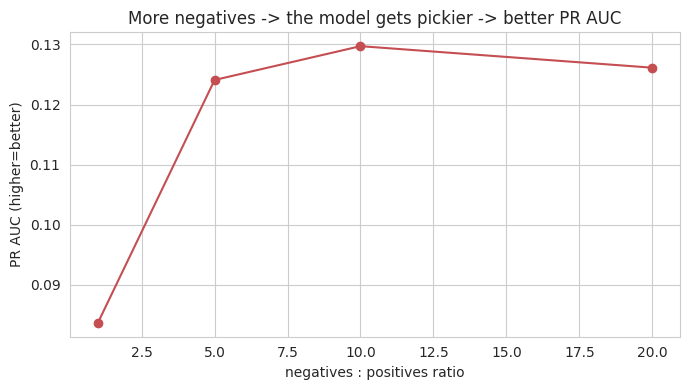

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(list(sweep), list(sweep.values()), "o-", color="#c44e52")
plt.xlabel("negatives : positives ratio"); plt.ylabel("PR AUC (higher=better)")
plt.title("More negatives -> the model gets pickier -> better PR AUC")
plt.tight_layout(); plt.show()

## 8 · Hyperparameter tuning

### ❓ Q7 — What is tuning, and how do we stay honest?
A model has knobs (**hyperparameters**): tree depth, learning rate, number of
trees… The defaults aren't always best. **Tuning** tries many combinations and
keeps the best.

To choose without cheating, we use **cross-validation on the training data**:
split it into folds, train on some, validate on the rest, average the score.
The **LI test set is never touched during tuning** — it stays a clean final exam.

We use `RandomizedSearchCV` (tries random combos — faster than trying all) and
score by **`average_precision`** (= PR AUC), because that's what we care about.

In [ ]:
from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

Xtr, ytr, enc = prep_fit(attach_account_features(ratio_subset(hi20, best_ratio), hi_feats))

space = {"n_estimators": randint(300, 700), "max_depth": randint(4, 10),
         "learning_rate": loguniform(1e-2, 1.5e-1),
         "subsample": uniform(0.6, 0.4), "colsample_bytree": uniform(0.6, 0.4),
         "min_child_weight": randint(1, 8), "gamma": loguniform(1e-3, 1.0),
         "reg_lambda": loguniform(1e-1, 1e1)}

search = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", n_jobs=1, random_state=SEED),
    space, n_iter=SEARCH_ITER, scoring="average_precision",
    cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
    n_jobs=SEARCH_JOBS, random_state=SEED, refit=True)
search.fit(Xtr, ytr)
best = search.best_estimator_; best.set_params(n_jobs=SEARCH_JOBS)
print("best CV PR AUC:", round(search.best_score_, 4))
print("best params:", search.best_params_)

best CV PR AUC: 0.9239
best params: {'colsample_bytree': np.float64(0.7529847965068651), 'gamma': np.float64(0.8906204386161677), 'learning_rate': np.float64(0.03539612815202284), 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 434, 'reg_lambda': np.float64(0.2193048555664369), 'subsample': np.float64(0.6260206371941118)}


## 9 · Final evaluation on the untouched LI test set

### ❓ Q8 — What's a **"good"** PR AUC here?
There's no universal cutoff — it depends on the **base rate**. A random guesser
scores PR AUC ≈ the positive fraction (~0.0005 here). So we also report the
**lift** = our PR AUC ÷ base rate. A lift of 100×–300× is a genuinely strong
model for data this imbalanced (serious graph-neural-net research on this exact
dataset operates in a similar range).

In [ ]:
def predict_chunked(model, raw, feats, enc, chunk=CHUNK):
    # transform + score the full test set in slices so RAM stays low
    probs = np.empty(len(raw), dtype=np.float32)
    for s in range(0, len(raw), chunk):
        part = raw.iloc[s:s+chunk]
        X = prep_apply(attach_account_features(part, feats), enc)
        probs[s:s+len(part)] = model.predict_proba(X)[:, 1]
        del X; gc.collect()
    return probs

proba = predict_chunked(best, li, li_feats, enc)     # full 3.46M, chunked
res = report("Tuned XGB", proba, y_test)
base_rate = y_test.mean()
print(f"\n  base rate (random PR AUC) ≈ {base_rate:.5f}")
print(f"  our PR AUC = {res['ap']:.4f}  ->  ~{res['ap']/base_rate:.0f}x better than random")
print()
print(classification_report(y_test, (proba >= 0.5).astype(int),
      target_names=["legit", "laundering"], digits=3, zero_division=0))

  Tuned XGB     PR AUC 0.1465 | ROC AUC 0.956 | prec@80%recall 0.0043

  base rate (random PR AUC) ≈ 0.00051
  our PR AUC = 0.1465  ->  ~285x better than random

              precision    recall  f1-score   support

       legit      1.000     0.997     0.998   3460242
  laundering      0.055     0.376     0.096      1782

    accuracy                          0.996   3462024
   macro avg      0.527     0.686     0.547   3462024
weighted avg      0.999     0.996     0.998   3462024



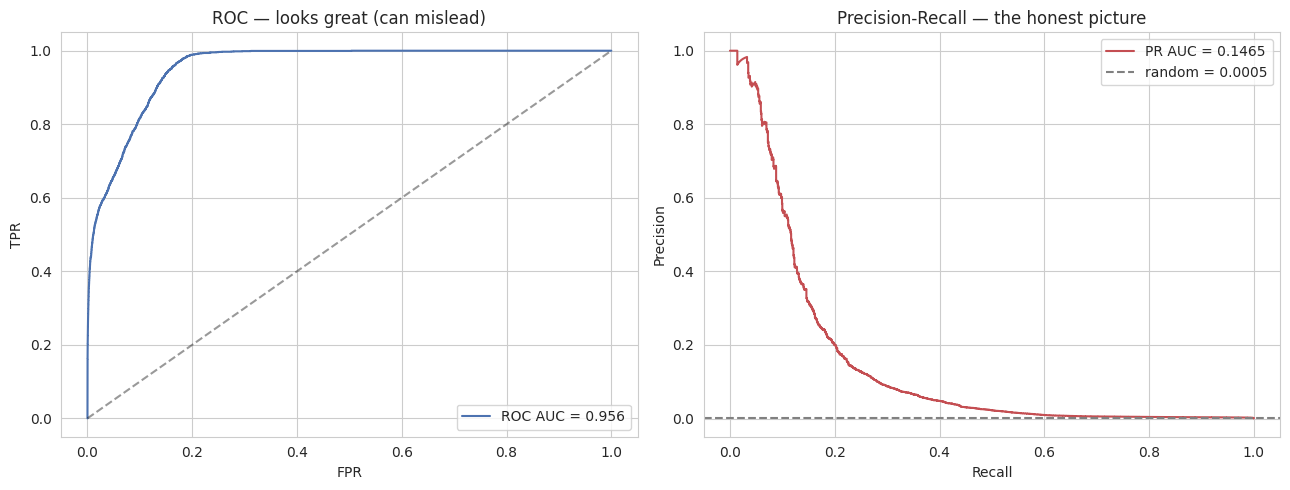

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fpr, tpr, _ = roc_curve(y_test, proba)
ax[0].plot(fpr, tpr, color="#4c72b0", label=f"ROC AUC = {res['auc']:.3f}")
ax[0].plot([0, 1], [0, 1], "k--", alpha=.4)
ax[0].set(title="ROC — looks great (can mislead)", xlabel="FPR", ylabel="TPR"); ax[0].legend()
prec, rec, _ = precision_recall_curve(y_test, proba)
ax[1].plot(rec, prec, color="#c44e52", label=f"PR AUC = {res['ap']:.4f}")
ax[1].axhline(base_rate, ls="--", color="grey", label=f"random = {base_rate:.4f}")
ax[1].set(title="Precision-Recall — the honest picture", xlabel="Recall", ylabel="Precision"); ax[1].legend()
plt.tight_layout(); plt.show()

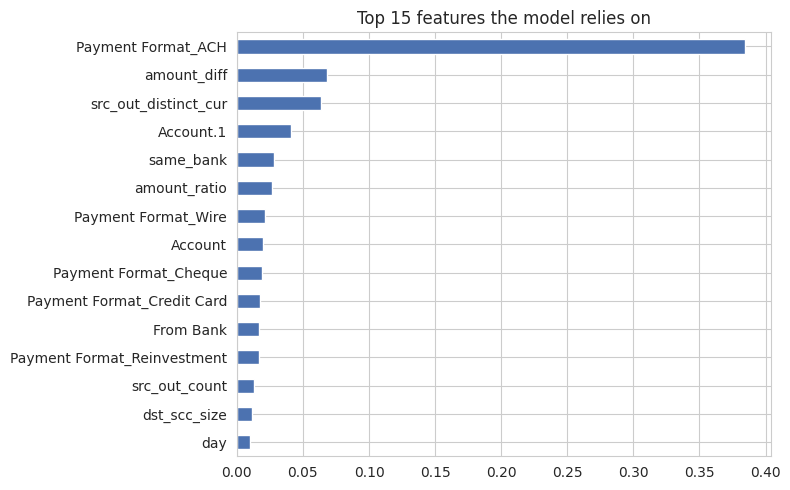

Notice how many of the top features are the src_/dst_ advanced (aggregation & graph) features we engineered!


In [ ]:
imp = pd.Series(best.feature_importances_, index=Xtr.columns).sort_values().tail(15)
plt.figure(figsize=(8, 5)); imp.plot(kind="barh", color="#4c72b0")
plt.title("Top 15 features the model relies on"); plt.tight_layout(); plt.show()
print("Notice how many of the top features are the src_/dst_ advanced "
      "(aggregation & graph) features we engineered!")

## 10 · The journey, in one table

| Stage | PR AUC (full LI) | vs baseline |
|---|---|---|
| Baseline features, 1:1 balance | 0.030 | — |
| + Advanced (graph + aggregation) features | 0.048 | 1.6× |
| + Hyperparameter tuning (1:1) | 0.084 | 2.8× |
| **+ 20:1 ratio + harder tuning** | **≈0.15** | **≈5×** |

Each idea in this notebook moved the needle. The two biggest wins were the
**advanced features** and the **20:1 undersampling ratio**.

## 11 · Use the model — score new transactions

A probability near 1 = likely laundering. You'd set a **threshold** based on how
many alerts your investigators can handle (lower threshold = catch more, but more
false alarms).

In [ ]:
def score(df, threshold=0.5):
    Xn = prep_apply(attach_account_features(df, li_feats), enc)
    p = best.predict_proba(Xn)[:, 1]
    out = df.copy(); out["laundering_probability"] = p.round(4)
    out["flagged"] = (p >= threshold).astype(int); return out

demo = pd.DataFrame([
    {"Timestamp": "2022/09/01 14:32", "From Bank": 33599, "Account": "817CC3FF0",
     "To Bank": 47381, "Account.1": "817CC4210", "Amount Received": 1878.02,
     "Receiving Currency": "Euro", "Amount Paid": 1878.02, "Payment Currency": "Euro",
     "Payment Format": "ACH"},
    {"Timestamp": "2022/09/02 03:11", "From Bank": 120229, "Account": "807B81920",
     "To Bank": 219353, "Account.1": "80808B140", "Amount Received": 48000.0,
     "Receiving Currency": "Bitcoin", "Amount Paid": 50000.0, "Payment Currency": "Bitcoin",
     "Payment Format": "Wire"}])
score(demo)[["Timestamp", "Amount Paid", "Payment Format", "laundering_probability", "flagged"]]

,Timestamp,Amount Paid,Payment Format,laundering_probability,flagged
0,2022/09/01 14:32,1878.02,ACH,0.8483,1
1,2022/09/02 03:11,50000.00,Wire,0.0037,0


In [ ]:
import joblib
os.makedirs("models", exist_ok=True)
joblib.dump(best, "models/aml_xgboost.joblib")
joblib.dump(enc,  "models/encoders.joblib")
print("Saved model + encoders to models/")

Saved model + encoders to models/


## 12 · Takeaways & how to go further

**What we learned**
- **Accuracy lies** on imbalanced data — use **PR AUC** and **precision@recall**.
- Laundering is a **network pattern**, so **graph features** (fan-in/out, cycles,
  PageRank) help far more than single-transaction features.
- **Undersampling** makes rare-event learning possible; the **ratio** is a real
  knob — 20:1 beat 1:1 here.
- **Tune for the metric you care about** (PR AUC), and keep the test set untouched.

**To push further** (heavier compute): Graph Neural Networks (GNNs) that learn
directly on the transaction graph; currency normalisation; account-level
sequence models. These can reach higher PR AUC but need GPUs/more time.

*You now understand every step of a real anti-money-laundering ML pipeline. 🎉*